# Gaussian Transformer: visual posterior-predictive check

This notebook loads a trained `GaussianTransformer`, selects one validation measure, and plots:

- the source point cloud $X$,
- the observed target point cloud $Y$,
- several independently sampled target point clouds from the learned predictive Gaussian
  $N(\hat m(X),\Sigma_Y)$.

All clouds are shown on the same axes so that the learned measure-to-measure map can be inspected visually.


In [1]:
from pathlib import Path
import sys

import torch
import matplotlib.pyplot as plt

# This notebook is intended to live in the same folder as train.py.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.gaussian_transformer import GaussianTransformer
from datasets import GaussianLocationDataset
from train import load_checkpoint


In [26]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

CHECKPOINT = Path("checkpoints/gaussian_transformer.pt")
NUM_MEASURES = 200
NUM_POINTS = 128

# These must match the dataset used for training/validation.
# Change them if your train.py used different values.
d = 2 

beta = torch.zeros(d)

Sigma_Z = torch.tensor([
    [1.0, 0.4],
    [0.4, 1.0],
])

Sigma_X = 0.25 * torch.eye(d)
Sigma_Y = 0.10 * torch.eye(d)

# Nontrivial linear map from latent source location to target location.
B0 = torch.tensor([
    [1.2, 0.2],
    [-0.1, 0.8],
])

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT.resolve()}")


Device: cpu
Checkpoint: C:\Users\some4561\OneDrive - Nexus365\Documents\DPhil\Project 2\m2m\simple_gaussian_example\checkpoints\gaussian_transformer.pt


In [27]:
# ---------------------------------------------------------------------
# Load checkpoint
# ---------------------------------------------------------------------

dataset = GaussianLocationDataset(
    num_measures=NUM_MEASURES,
    num_samples=NUM_POINTS,
    beta=beta,
    Sigma_Z=Sigma_Z,
    Sigma_X=Sigma_X,
    Sigma_Y=Sigma_Y,
    B0=B0,
    seed=1,
)

model = GaussianTransformer(
    d=dataset.d,
    Ly=dataset.Ly,
    hidden_dim=128,
    num_heads=4,
    num_layers=3,
    ff_dim=256,
    dropout=0.0,
)

model, _, epoch, history, extra = load_checkpoint(
    CHECKPOINT,
    model,
    optimizer=None,
    device=DEVICE,
)

model.eval()

print(f"Loaded checkpoint from epoch: {epoch}")
if history is not None:
    print(f"Last train NLL: {history['train_nll'][-1]:.6f}")
    if history.get('val_nll'):
        print(f"Last validation NLL: {history['val_nll'][-1]:.6f}")


Loaded checkpoint from epoch: 50
Last train NLL: 72.359005
Last validation NLL: 70.587707


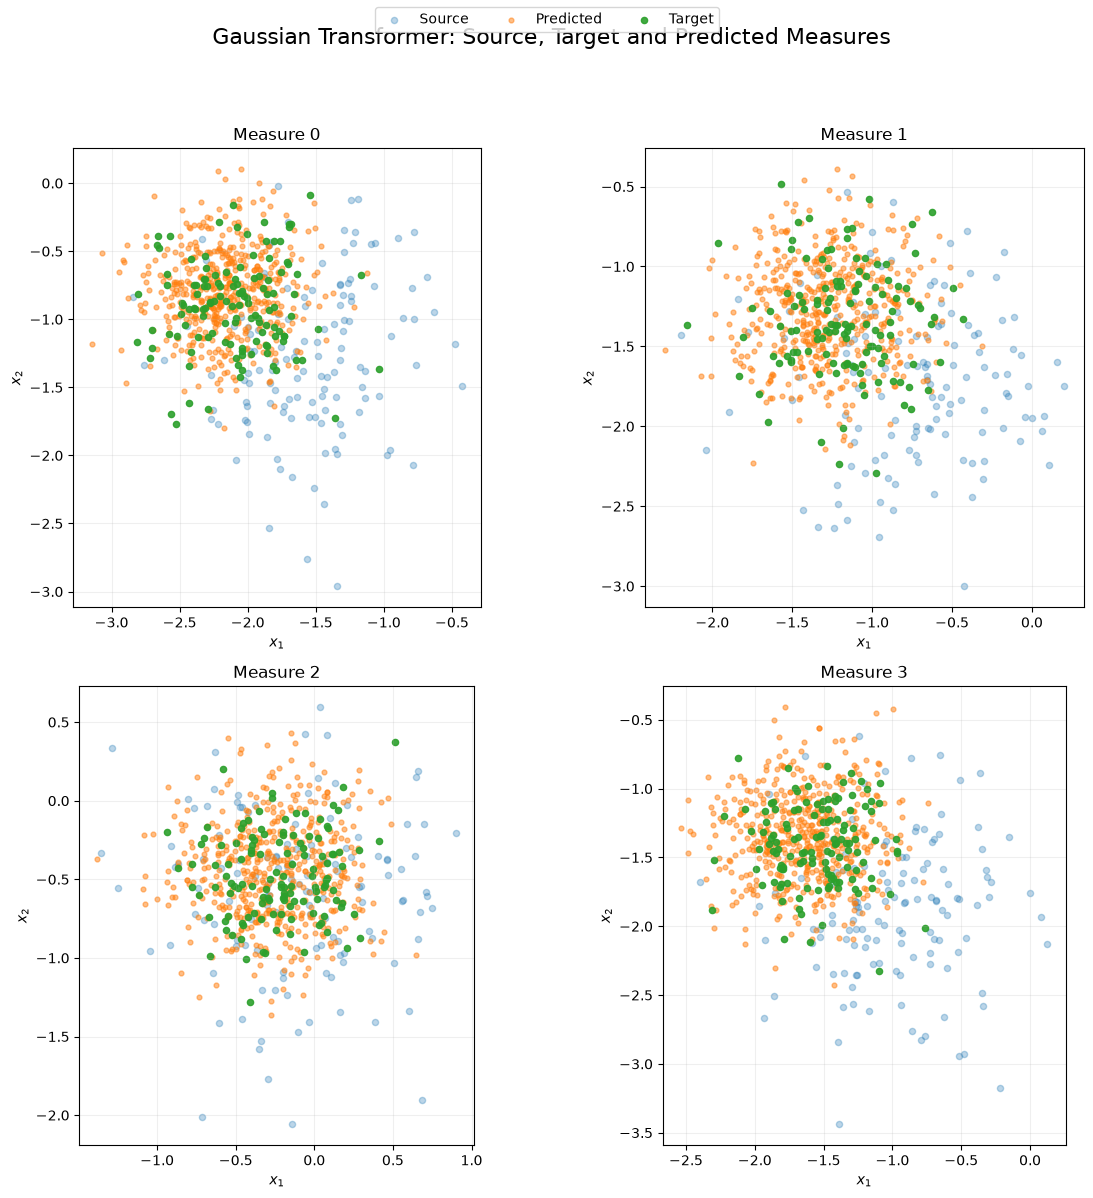

In [30]:
NUM_MEASURES = 4
NUM_PREDICTIVE_POINTS = 500

model.eval()

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12),
)

axes = axes.flatten()

for ax, idx in zip(axes, range(NUM_MEASURES)):

    # -------------------------------------------------------------
    # Get source and target measure
    # -------------------------------------------------------------

    source, target, latent_z = dataset[idx]

    source_b = (
        source
        .unsqueeze(0)
        .to(DEVICE)
    )

    # -------------------------------------------------------------
    # Predict Gaussian mean
    # -------------------------------------------------------------

    with torch.no_grad():

        predicted_mean = model(source_b)[0]

        # ---------------------------------------------------------
        # Draw 500 points from predicted measure
        #
        # Y_hat ~ N(predicted_mean, Sigma_Y)
        # ---------------------------------------------------------

        eps = torch.randn(
            NUM_PREDICTIVE_POINTS,
            dataset.d,
            device=DEVICE,
        )

        predicted_points = (
            predicted_mean.unsqueeze(0)
            + eps @ model.Ly.T
        )

    predicted_points = predicted_points.cpu()
    predicted_mean = predicted_mean.cpu()

    # -------------------------------------------------------------
    # Plot
    # -------------------------------------------------------------

    ax.scatter(
        source[:, 0],
        source[:, 1],
        s=20,
        alpha=0.3,
        label="Source",
    )
    
    ax.scatter(
        predicted_points[:, 0],
        predicted_points[:, 1],
        s=12,
        alpha=0.5,
        label="Predicted",
    )

    ax.scatter(
        target[:, 0],
        target[:, 1],
        s=20,
        alpha=0.9,
        label="Target",
    )

    ax.set_title(f"Measure {idx}")

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.grid(alpha=0.2)


# Use one common legend rather than four separate legends
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
)

fig.suptitle(
    "Gaussian Transformer: Source, Target and Predicted Measures",
    fontsize=16,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()